# 02 - Hash Tables From Scratch

The dictionary is the data structure you use more than any other, and the one you are least likely
to have opened. This notebook builds it twice.

The idea from notebook 01 - *compute the address instead of searching for it* - has one problem:
two different keys can compute the same address. That is a **collision**, and how you handle it is
the only real design decision in a hash table:

* **chaining** - the slot holds a list; colliding keys live in it together;
* **open addressing** - the colliding key moves to the next free slot.

Both are here, both count their probes, and the point of the notebook is the figure near the end:
lookup cost stays flat as the table fills, and then it does not. That cliff is why Python's `dict`
resizes itself behind your back, and it is why *collisions* are the central concern of every
structure in the rest of this project.

In [1]:
%matplotlib inline

import time

import pandas as pd

from src.config import get_settings
from src.core.hashtable import ChainingHashTable, OpenAddressingHashTable
from src.results import results_dir, save_results
from src.visualisation import (
    plot_capacity_growth,
    plot_chain_lengths,
    plot_probe_cost,
    plot_table_occupancy,
    save_figure,
)

SETTINGS = get_settings()
SEED = SETTINGS.seed
DEMO_ITEMS = SETTINGS.hashtable.demo_items

print(f"seed = {SEED}, demo items = {DEMO_ITEMS:,}")

seed = 20260903, demo items = 20,000


## It has to behave exactly like a dict

Before any performance story, the thing has to be correct: insert, look up, overwrite, delete,
report length. Here it is checked against the built-in `dict` over a few thousand random
operations, which is also what `tests/test_hashtable.py` does on every CI run.

In [2]:
table = ChainingHashTable(capacity=SETTINGS.hashtable.initial_capacity, seed=SEED)
oracle = {}

for i in range(5_000):
    key = f"key-{i % 900}"
    table[key] = i
    oracle[key] = i

for key in ("key-0", "key-450", "key-899"):
    del table[key]
    del oracle[key]

agrees = len(table) == len(oracle) and all(table[key] == value for key, value in oracle.items())
missing_is_absent = "key-0" not in table and "key-0" not in oracle

print(f"same contents as dict: {agrees}")
print(f"deleted keys really gone: {missing_is_absent}")
print(f"{len(table):,} items in {table.capacity:,} slots "
      f"(load factor {table.load_factor:.2f}, {table.n_resizes} resizes so far)")

same contents as dict: True
deleted keys really gone: True
897 items in 2,048 slots (load factor 0.44, 7 resizes so far)


## Chaining: collisions share a slot

With a good hash, the number of keys landing in one slot follows a Poisson distribution. At load
factor 0.75 most slots hold zero or one item and a handful hold three - so an average lookup walks
about one entry, and the worst case is small rather than catastrophic.

This is the graceful failure mode: at load factor 4 a lookup walks about 4 entries. Slow, but it
never stops working.

load factor 0.75
empty slots: 1,912 of 4,096
longest chain: 5 items


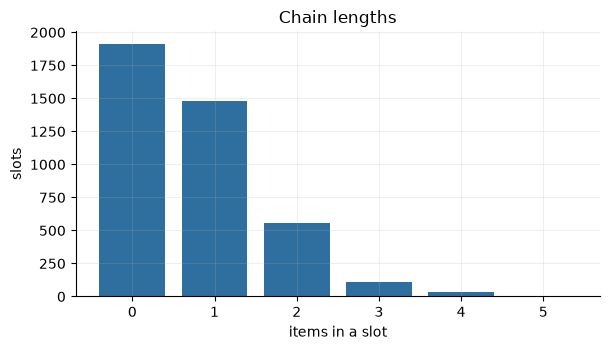

In [3]:
chained = ChainingHashTable(capacity=4_096, auto_resize=False, seed=SEED)
for i in range(3_072):  # load factor 0.75
    chained[f"key-{i:06d}"] = i

lengths = chained.bucket_lengths()
occupied = sum(1 for length in lengths if length > 0)

print(f"load factor {chained.load_factor:.2f}")
print(f"empty slots: {len(lengths) - occupied:,} of {len(lengths):,}")
print(f"longest chain: {max(lengths)} items")

figure = plot_chain_lengths(lengths)
save_figure(figure, "02_chain_lengths")
figure

In [4]:
saved = save_results(
    {
        "capacity": chained.capacity,
        "n_items": len(chained),
        "load_factor": chained.load_factor,
        "empty_slots": len(lengths) - occupied,
        "longest_chain": max(lengths),
        "chain_length_histogram": pd.Series(lengths).value_counts().sort_index().to_dict(),
        "memory_bytes": chained.memory_bytes(),
    },
    "02_chaining",
)
print("saved ->", saved.name)

saved -> 02_chaining.json


## Open addressing: collisions move along

No lists, no pointers - one flat array, and a colliding key simply takes the next free slot. That
is why it is fast in practice: the probe sequence is a linear walk through contiguous memory, which
is exactly what a CPU cache likes.

Deleting is the subtle part. You cannot just empty a slot: doing so would cut a probe sequence in
half and make every key behind the hole unreachable. So a deletion leaves a **tombstone** that
lookups walk past and inserts may reuse.

The strip below is the table itself - filled slots dark, free slots light. Watch the clusters:
once a run of occupied slots forms, it attracts more keys, which is precisely why linear probing
degrades sharply near a full table.

mean probes per successful lookup: 1.86
deleted key gone: True; every other key still reachable: True
tombstones: 1


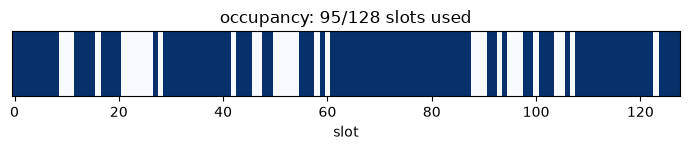

In [5]:
probing = OpenAddressingHashTable(capacity=128, auto_resize=False, seed=SEED)
for i in range(96):  # load factor 0.75
    probing[f"key-{i:04d}"] = i

probing.reset_probe_stats()
for i in range(96):
    _ = probing[f"key-{i:04d}"]
before = probing.probe_stats()

del probing["key-0042"]
tombstoned = "key-0042" not in probing
still_reachable = all(probing[f"key-{i:04d}"] == i for i in range(96) if i != 42)

print(f"mean probes per successful lookup: {before.mean_probes:.2f}")
print(f"deleted key gone: {tombstoned}; every other key still reachable: {still_reachable}")
print(f"tombstones: {probing.n_tombstones}")

figure = plot_table_occupancy(probing.occupancy())
save_figure(figure, "02_occupancy")
figure

## The figure: lookup cost against load factor

Now the point of the whole notebook. Fill a table to a given load factor, look up every key it
holds, and count probes. Theory says:

* **chaining**: about `1 + a/2` probes for a successful lookup - linear in the load factor `a`, so
  it degrades gently;
* **linear probing**: about `(1 + 1/(1-a))/2` - which explodes as `a` approaches 1, because
  `1/(1-a)` does.

At `a = 0.5` linear probing wins (1.5 probes against 1.25, in a flat array rather than a linked
structure). At `a = 0.95` it costs about 10 probes and climbing. That is the wall.

In [6]:
load_factors = [0.1, 0.25, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95]
capacity = 8_192
rows = []

for load_factor in load_factors:
    n_items = int(capacity * load_factor)
    keys = [f"key-{i:06d}" for i in range(n_items)]
    for name, table_class in (
        ("chaining", ChainingHashTable),
        ("open addressing", OpenAddressingHashTable),
    ):
        table = table_class(capacity=capacity, max_load_factor=1.0, auto_resize=False, seed=SEED)
        for i, key in enumerate(keys):
            table[key] = i
        table.reset_probe_stats()
        start = time.perf_counter()
        for key in keys:
            _ = table[key]
        seconds = time.perf_counter() - start
        stats = table.probe_stats()
        theory = (
            1 + load_factor / 2
            if name == "chaining"
            else (1 + 1 / (1 - load_factor)) / 2
        )
        rows.append(
            {
                "strategy": name,
                "load_factor": load_factor,
                "n_items": n_items,
                "mean_probes": stats.mean_probes,
                "theory_probes": theory,
                "microseconds_per_lookup": 1e6 * seconds / n_items,
            }
        )

probe_costs = pd.DataFrame(rows)
probe_costs.pivot(index="load_factor", columns="strategy", values="mean_probes").round(2)

strategy,chaining,open addressing
load_factor,,
0.10,1.05,1.06
0.25,1.12,1.16
0.40,1.20,1.34
0.50,1.25,1.51
0.60,1.31,1.79
0.70,1.36,2.28
0.80,1.40,3.22
0.90,1.45,5.46
0.95,1.48,10.17


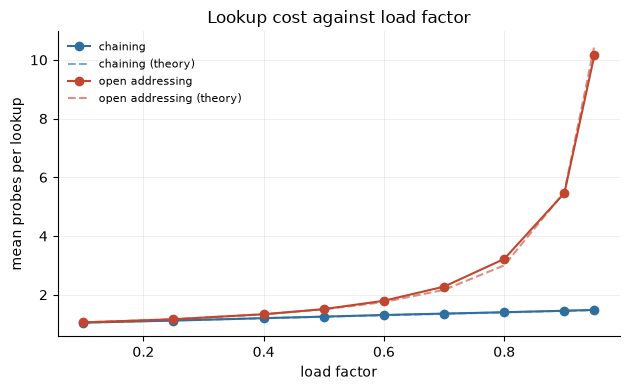

In [7]:
figure = plot_probe_cost(probe_costs)
save_figure(figure, "02_probe_cost")
figure

In [8]:
saved = save_results(
    {
        "capacity": capacity,
        "probe_costs": probe_costs,
        "theory": {
            "chaining_successful_lookup": "1 + a/2",
            "linear_probing_successful_lookup": "(1 + 1/(1 - a))/2",
        },
        "note": (
            "Measured probe counts track theory closely enough that the wall near a = 1 is a "
            "property of the method, not of this implementation."
        ),
    },
    "02_probe_cost",
)
print("saved ->", saved.name)

saved -> 02_probe_cost.json


## Which is why a dictionary resizes itself

If cost explodes as the table fills, keep the table from filling. Every real hash table - Python's
`dict` included - watches its load factor and, when it crosses a threshold, allocates a bigger
array and rehashes everything into it.

Rehashing 20,000 items sounds expensive, and it is: that single insert costs O(n). But it happens
after 20,000 cheap inserts, and the capacity *doubles*, so the cost per insert averaged over the
whole run stays constant. That is what "amortised O(1)" means, and the staircase below is it.

20,000 inserts in 0.18s (9.2 microseconds each, amortised)
11 resizes, final capacity 32,768, load factor 0.61 (cap 0.75)


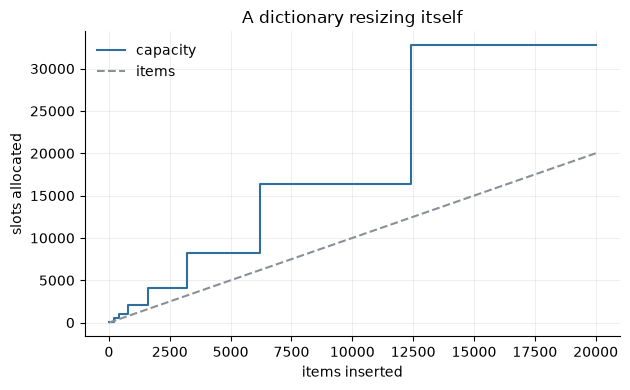

In [9]:
growing = ChainingHashTable(
    capacity=SETTINGS.hashtable.initial_capacity,
    max_load_factor=SETTINGS.hashtable.max_load_factor,
    seed=SEED,
)
rows = []
start = time.perf_counter()
for i in range(1, DEMO_ITEMS + 1):
    growing[f"key-{i:06d}"] = i
    if i % 200 == 0 or i == 1:
        rows.append(
            {
                "n_items": i,
                "capacity": growing.capacity,
                "load_factor": growing.load_factor,
                "n_resizes": growing.n_resizes,
            }
        )
insert_seconds = time.perf_counter() - start

capacity_growth = pd.DataFrame(rows)

print(f"{DEMO_ITEMS:,} inserts in {insert_seconds:.2f}s "
      f"({1e6 * insert_seconds / DEMO_ITEMS:.1f} microseconds each, amortised)")
print(f"{growing.n_resizes} resizes, final capacity {growing.capacity:,}, "
      f"load factor {growing.load_factor:.2f} (cap {growing.max_load_factor})")

figure = plot_capacity_growth(capacity_growth)
save_figure(figure, "02_capacity_growth")
figure

In [10]:
saved = save_results(
    {
        "n_items": DEMO_ITEMS,
        "n_resizes": growing.n_resizes,
        "final_capacity": growing.capacity,
        "final_load_factor": growing.load_factor,
        "max_load_factor": growing.max_load_factor,
        "insert_seconds": insert_seconds,
        "microseconds_per_insert_amortised": 1e6 * insert_seconds / DEMO_ITEMS,
        "capacity_growth": capacity_growth,
    },
    "02_resizing",
)
print("saved ->", saved.name)

saved -> 02_resizing.json


## What to take away

- A hash table is a hash plus an answer to "what happens when two keys collide". Chaining shares a
  slot; open addressing moves along the array.
- Lookup cost is probe count, and probe count depends on the **load factor**, not on the number of
  items. That is why a dictionary is O(1): it keeps the load factor bounded by resizing.
- Chaining degrades linearly (`1 + a/2`); linear probing degrades like `1/(1-a)`, which is fine
  until it very much is not.
- Deletion in open addressing needs tombstones. Emptying a slot outright silently loses keys - the
  first appearance of a theme this project keeps returning to: the *deletion* case is where these
  structures get subtle.
- Collisions are not an edge case; they are the design. Everything after this notebook manages
  collisions on purpose, and even *chooses* to accept them in exchange for memory.

Next: keep the hash, throw away the keys, and see what a table of bits can still tell you.

In [11]:
takeaways = [
    "A hash table is a hash plus a collision policy: chaining or open addressing.",
    "Cost depends on the load factor, not the item count - which is why dicts resize themselves.",
    "Chaining degrades like 1 + a/2; linear probing degrades like (1 + 1/(1-a))/2.",
    "Open-addressing deletes need tombstones, or keys behind the hole become unreachable.",
    "Collisions are the central design concern of every structure in this project.",
]

saved = save_results({"takeaways": takeaways}, "02_takeaways")
print("saved ->", saved.name)
print("figures:", sorted(path.name for path in SETTINGS.figures.path.glob("02_*.png")))
print("results:", sorted(path.name for path in results_dir().glob("02_*.json")))

saved -> 02_takeaways.json
figures: ['02_capacity_growth.png', '02_chain_lengths.png', '02_occupancy.png', '02_probe_cost.png']
results: ['02_chaining.json', '02_probe_cost.json', '02_resizing.json', '02_takeaways.json']
